# Opis
Celem projektu jest zbudowanie i przetrenowanie modelu sztucznej inteligencji, który potrafi rozpoznawać emocje na ludzkiej twarzy na podstawie zdjęcia. Dane wejściowe stanowi przygotowany zbiór obrazów „Human Face Emotions”, w którym zdjęcia są posegregowane w folderach odpowiadających poszczególnym kategoriom emocji (happy, sad). Najlepszy model uzyskał 92% skuteczności.

In [118]:
!pip install tensorflow

In [119]:
#Dane
#https://www.kaggle.com/datasets/samithsachidanandan/human-face-emotions

In [120]:
import tensorflow as tf
from pathlib import Path

In [121]:
data_dir = Path("C:/Users/Mariusz/OneDrive/Pulpit/StudiaPodyplomowe/Projekty_do CV/emotions_project/Data")

In [122]:
print("Wersja TF:", tf.__version__)
print("Wszystkie urządzenia:", tf.config.list_physical_devices())
print("Urządzenia GPU:", tf.config.list_physical_devices('GPU'))

Wersja TF: 2.20.0
Wszystkie urządzenia: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]
Urządzenia GPU: []


In [123]:
IMG_SIZE = (128, 128)
BATCH_SIZE = 32

# 80% train, 20% test
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    labels="inferred",
    label_mode="int",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    validation_split=0.2,   
    subset="training",       
    seed=123,                
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    labels="inferred",
    label_mode="int",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,           
    validation_split=0.2,    
    subset="validation",     
    seed=123,               
)

class_names = train_ds.class_names
print("Klasy:", class_names)

Found 30992 files belonging to 2 classes.
Using 24794 files for training.
Found 30992 files belonging to 2 classes.
Using 6198 files for validation.
Klasy: ['Happy', 'Sad']


In [124]:
counts = np.zeros(len(class_names), dtype=int)

for _, labels in train_ds.unbatch():
    counts[labels.numpy()] += 1

for i, name in enumerate(class_names):
    print(f"{name}: {counts[i]} próbek w train_ds")

Happy: 14766 próbek w train_ds
Sad: 10028 próbek w train_ds


In [125]:
import numpy as np

counts = np.zeros(len(class_names), dtype=int)

for _, labels in test_ds.unbatch():
    counts[labels.numpy()] += 1

for i, name in enumerate(class_names):
    print(f"{name}: {counts[i]} próbek w test_ds")

Happy: 3673 próbek w test_ds
Sad: 2525 próbek w test_ds


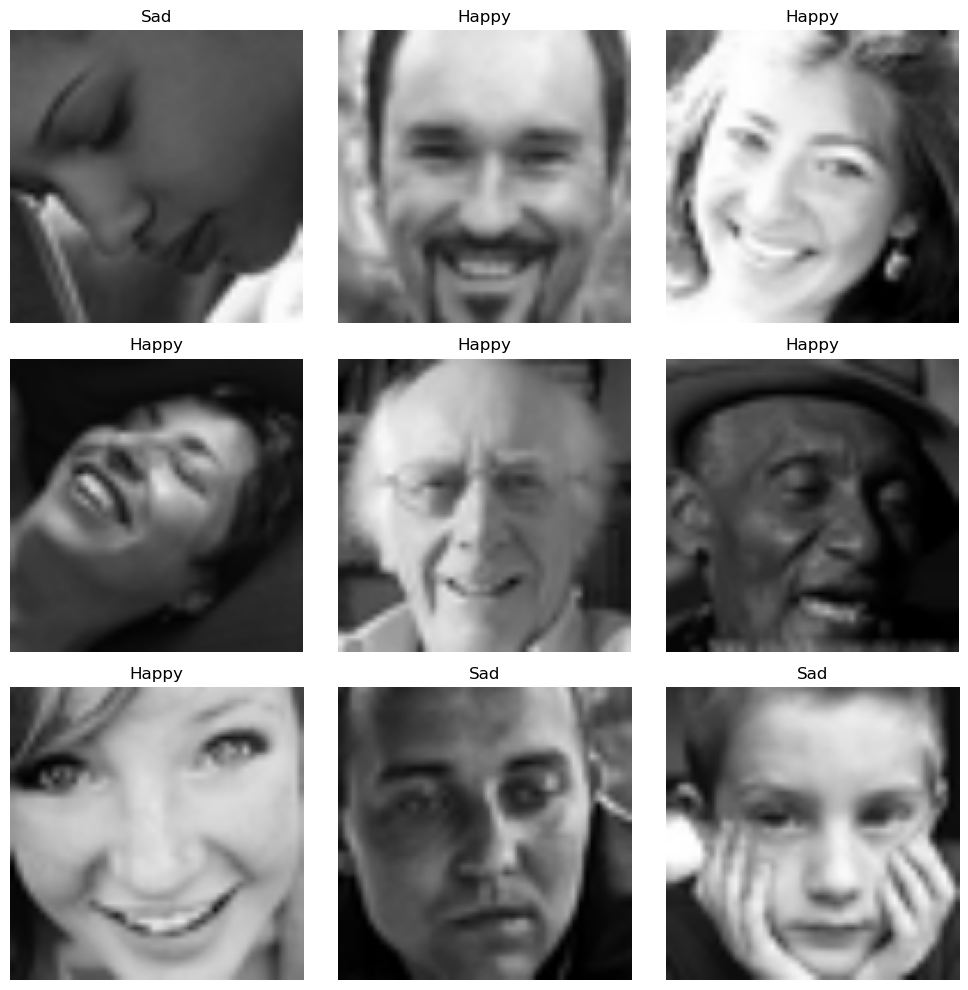

In [126]:
import matplotlib.pyplot as plt


images, labels = next(iter(train_ds))

plt.figure(figsize=(10, 10))

for i in range(9):  
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))   
    plt.title(class_names[labels[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()


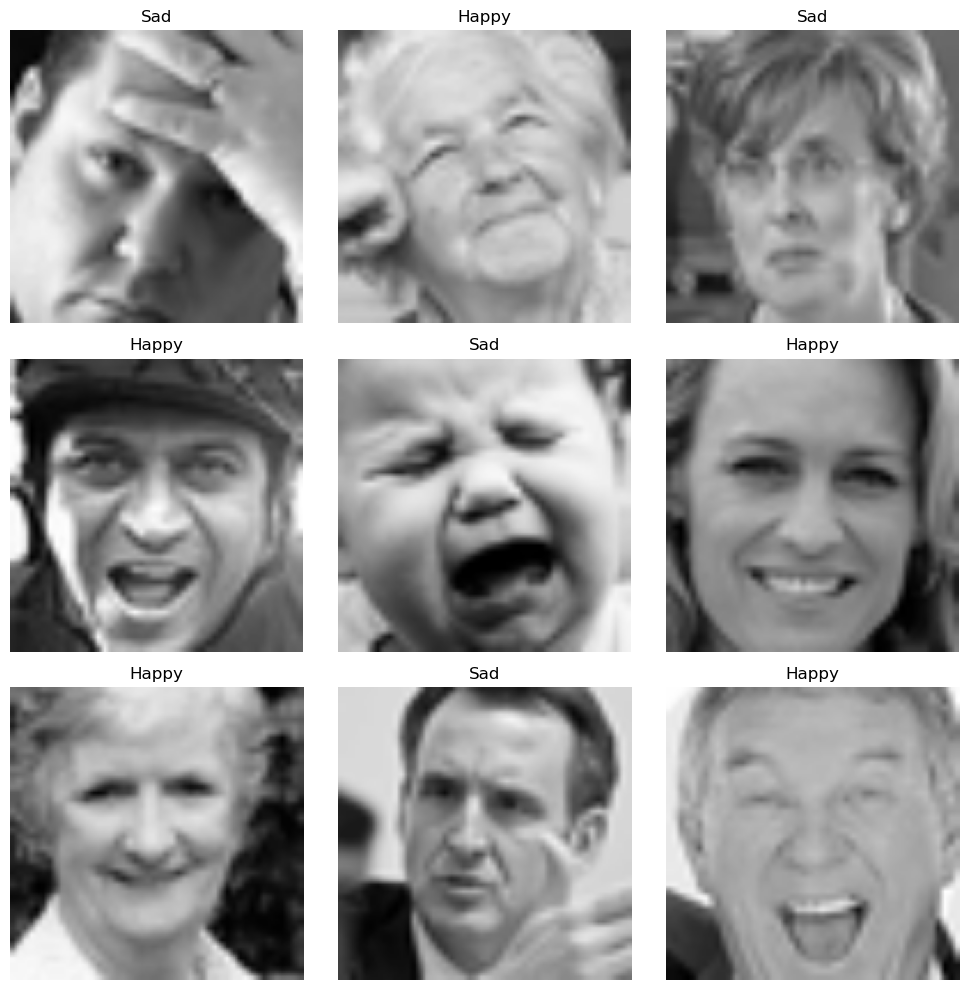

In [127]:
import matplotlib.pyplot as plt


images, labels = next(iter(train_ds))

plt.figure(figsize=(10, 10))

for i in range(9):   # 3x3 obrazki
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))   # obrazy są w [0,255]
    plt.title(class_names[labels[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [128]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),   # odbicie w poziomie
    tf.keras.layers.RandomRotation(0.05),       # lekkie obroty (~±5%)
    tf.keras.layers.RandomZoom(0.1),            # mały zoom
], name="data_augmentation")

In [129]:
AUTOTUNE = tf.data.AUTOTUNE

def preprocess_train(images, labels):
    images = tf.cast(images, tf.float32)
    images = data_augmentation(images)      
    images = images / 255.0                 
    return images, labels

def preprocess_test(images, labels):
    images = tf.cast(images, tf.float32) / 255.0
    return images, labels

train_ds = (train_ds
                 .map(preprocess_train, num_parallel_calls=AUTOTUNE)
                 .prefetch(AUTOTUNE))

test_ds  = (test_ds
                 .map(preprocess_test, num_parallel_calls=AUTOTUNE)
                 .prefetch(AUTOTUNE))

In [130]:
images, labels = next(iter(train_ds))
print(images.shape, labels.shape)
print(images.dtype, images.numpy().min(), images.numpy().max())

(32, 128, 128, 3) (32,)
<dtype: 'float32'> 0.0 1.0


Kształt batcha: (32, 128, 128, 3)
Etykiety: [1 1 1 0 1 0 1 0 1 1]


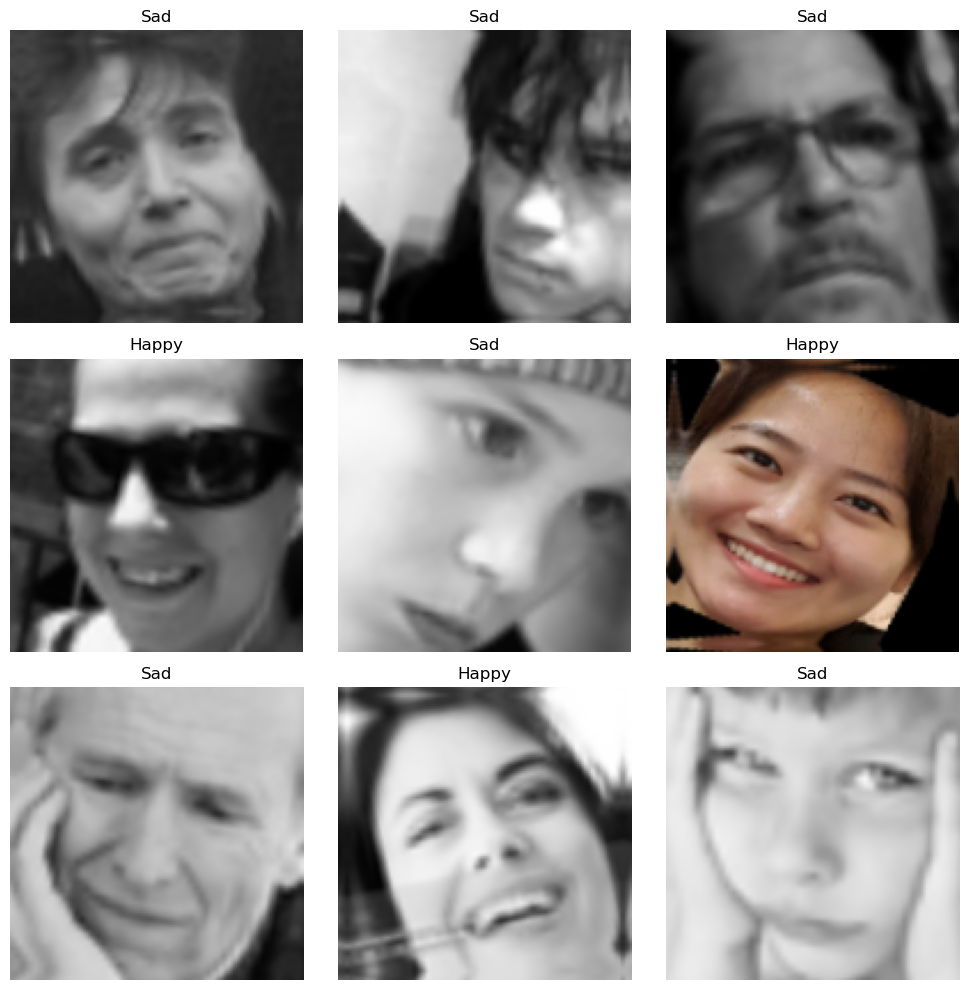

In [131]:
images, labels = next(iter(train_ds))

print("Kształt batcha:", images.shape)
print("Etykiety:", labels[:10].numpy())

plt.figure(figsize=(10, 10))

for i in range(9): 
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy())
    plt.title(class_names[labels[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

Kształt batcha: (32, 128, 128, 3)
Etykiety: [1 1 1 1 1 1 0 0 0 1]


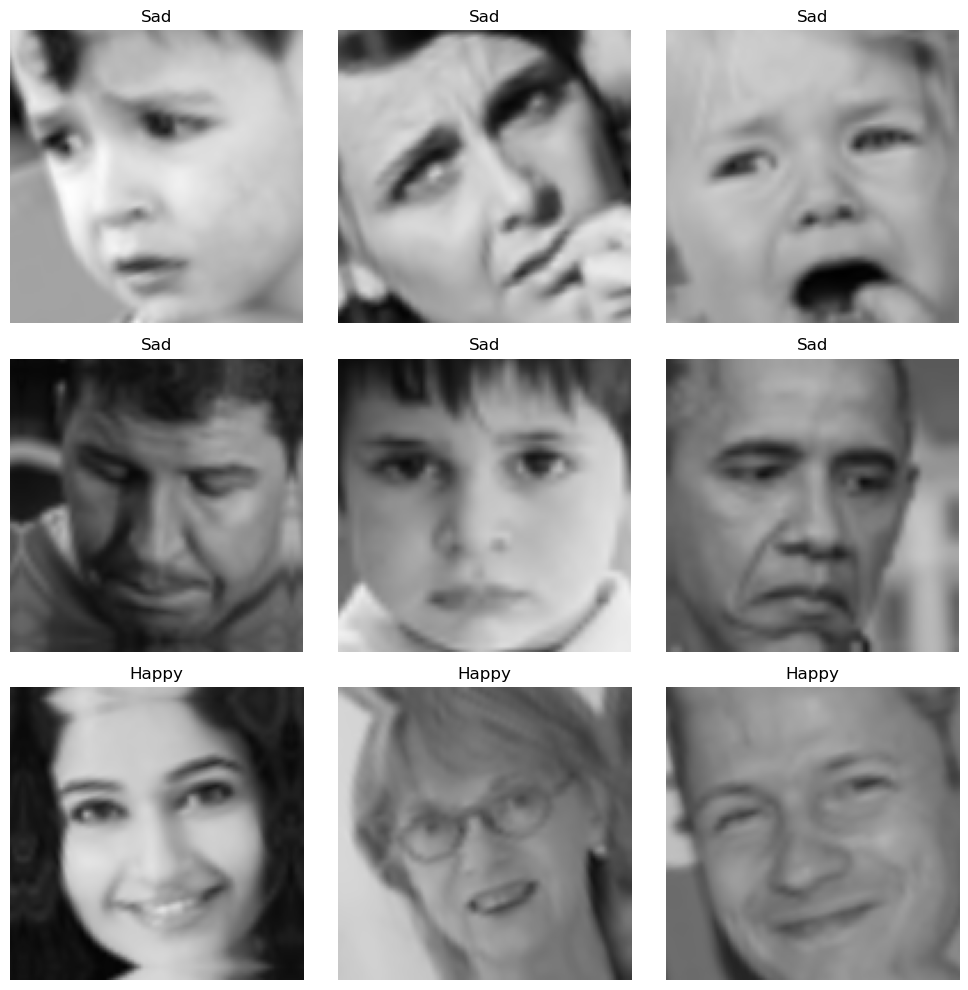

In [132]:
images, labels = next(iter(train_ds))

print("Kształt batcha:", images.shape)
print("Etykiety:", labels[:10].numpy())

plt.figure(figsize=(10, 10))

for i in range(9): 
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy())
    plt.title(class_names[labels[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

# Model 1

In [133]:
num_classes = len(class_names)
print("Liczba klas:", num_classes, class_names)

model = tf.keras.Sequential([
    tf.keras.layers.InputLayer(input_shape=IMG_SIZE + (3,)),

    tf.keras.layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128, (3, 3), padding="same", activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(num_classes, activation="softmax"),
])

model.summary()

Liczba klas: 2 ['Happy', 'Sad']


G:\programy\Lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_14 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,287,938 (16.36 MB)

 Trainable params: 4,287,938 (16.36 MB)

 Non-trainable params: 0 (0.00 B)

In [134]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

In [135]:
EPOCHS = 5

history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=EPOCHS,
)

Epoch 1/5
775/775 ━━━━━━━━━━━━━━━━━━━━ 165s 210ms/step - accuracy: 0.6124 - loss: 0.6589 - val_accuracy: 0.6675 - val_loss: 0.6032
Epoch 2/5
775/775 ━━━━━━━━━━━━━━━━━━━━ 152s 196ms/step - accuracy: 0.6844 - loss: 0.5845 - val_accuracy: 0.7667 - val_loss: 0.4758
Epoch 3/5
775/775 ━━━━━━━━━━━━━━━━━━━━ 150s 193ms/step - accuracy: 0.7370 - loss: 0.5142 - val_accuracy: 0.7928 - val_loss: 0.4368
Epoch 4/5
775/775 ━━━━━━━━━━━━━━━━━━━━ 151s 195ms/step - accuracy: 0.7647 - loss: 0.4733 - val_accuracy: 0.8132 - val_loss: 0.3989
Epoch 5/5
775/775 ━━━━━━━━━━━━━━━━━━━━ 151s 194ms/step - accuracy: 0.7806 - loss: 0.4462 - val_accuracy: 0.8167 - val_loss: 0.3833


In [136]:
from tensorflow.keras.callbacks import EarlyStopping

EPOCHS_TOTAL = 20  # maksymalnie

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,        # jeśli przez 3 epoki nie poprawi się val_loss -> stop
    restore_best_weights=True,
)

history2 = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=EPOCHS_TOTAL,
    callbacks=[early_stop],
)

model.save("emotion_cnn.h5")

print("Model zapisany do pliku emotion_cnn.h5")

Epoch 1/20
775/775 ━━━━━━━━━━━━━━━━━━━━ 151s 194ms/step - accuracy: 0.7947 - loss: 0.4221 - val_accuracy: 0.8340 - val_loss: 0.3604
Epoch 2/20
775/775 ━━━━━━━━━━━━━━━━━━━━ 148s 190ms/step - accuracy: 0.8114 - loss: 0.4021 - val_accuracy: 0.8425 - val_loss: 0.3440
Epoch 3/20
775/775 ━━━━━━━━━━━━━━━━━━━━ 148s 191ms/step - accuracy: 0.8180 - loss: 0.3918 - val_accuracy: 0.8498 - val_loss: 0.3278
Epoch 4/20
775/775 ━━━━━━━━━━━━━━━━━━━━ 147s 190ms/step - accuracy: 0.8258 - loss: 0.3818 - val_accuracy: 0.8516 - val_loss: 0.3346
Epoch 5/20
775/775 ━━━━━━━━━━━━━━━━━━━━ 148s 191ms/step - accuracy: 0.8262 - loss: 0.3720 - val_accuracy: 0.8571 - val_loss: 0.3160
Epoch 6/20
775/775 ━━━━━━━━━━━━━━━━━━━━ 148s 191ms/step - accuracy: 0.8352 - loss: 0.3620 - val_accuracy: 0.8653 - val_loss: 0.3083
Epoch 7/20
775/775 ━━━━━━━━━━━━━━━━━━━━ 147s 190ms/step - accuracy: 0.8375 - loss: 0.3533 - val_accuracy: 0.8648 - val_loss: 0.2989
Epoch 8/20
775/775 ━━━━━━━━━━━━━━━━━━━━ 150s 193ms/step - accuracy: 0.8404 -

Model zapisany do pliku emotion_cnn.h5


In [137]:
test_loss, test_acc = model.evaluate(test_ds)
print("Test loss:", test_loss)
print("Test accuracy:", test_acc)

194/194 ━━━━━━━━━━━━━━━━━━━━ 9s 46ms/step - accuracy: 0.8800 - loss: 0.2719
Test loss: 0.27191776037216187
Test accuracy: 0.8799612522125244


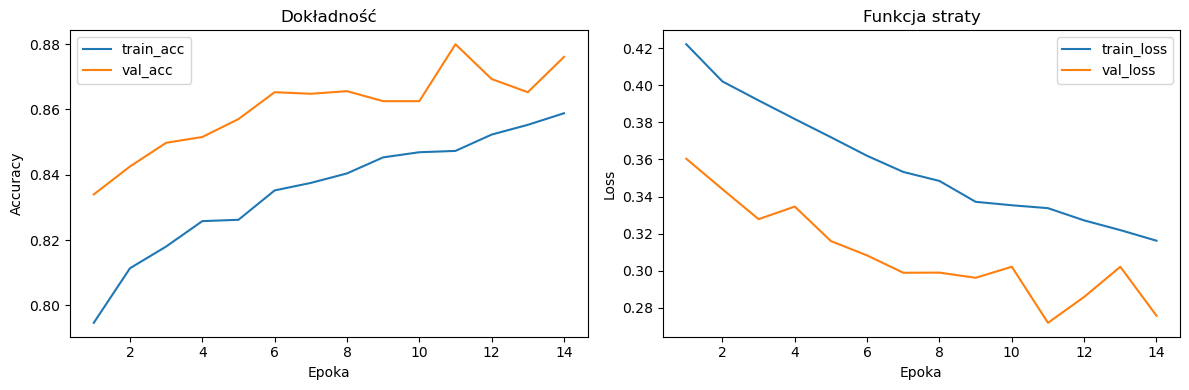

In [138]:
import matplotlib.pyplot as plt

acc = history2.history["accuracy"]
val_acc = history2.history["val_accuracy"]
loss = history2.history["loss"]
val_loss = history2.history["val_loss"]

epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label="train_acc")
plt.plot(epochs_range, val_acc, label="val_acc")
plt.xlabel("Epoka")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Dokładność")

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label="train_loss")
plt.plot(epochs_range, val_loss, label="val_loss")
plt.xlabel("Epoka")
plt.ylabel("Loss")
plt.legend()
plt.title("Funkcja straty")

plt.tight_layout()
plt.show()

# Model 2

In [139]:
num_classes = len(class_names)
print("Klasy:", class_names)

model_big = tf.keras.Sequential([
    tf.keras.layers.InputLayer(input_shape=IMG_SIZE + (3,)),

    # Blok 1
    tf.keras.layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(),

    # Blok 2
    tf.keras.layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(),

    # Blok 3
    tf.keras.layers.Conv2D(128, (3, 3), padding="same", activation="relu"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(),

    # Blok 4
    tf.keras.layers.Conv2D(256, (3, 3), padding="same", activation="relu"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(),
    
    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dense(256, activation="relu"),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(num_classes, activation="softmax"),
])

model_big.summary()

Klasy: ['Happy', 'Sad']


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_17 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 456,642 (1.74 MB)

 Trainable params: 455,682 (1.74 MB)

 Non-trainable params: 960 (3.75 KB)

In [140]:
model_big.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

early_stop_big = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
)

In [141]:
EPOCHS_BIG = 50  # max

history_big = model_big.fit(
    train_ds,
    validation_data=test_ds,
    epochs=EPOCHS_BIG,
    callbacks=[early_stop_big],
)

Epoch 1/50
775/775 ━━━━━━━━━━━━━━━━━━━━ 330s 422ms/step - accuracy: 0.6126 - loss: 0.6628 - val_accuracy: 0.5523 - val_loss: 0.6866
Epoch 2/50
775/775 ━━━━━━━━━━━━━━━━━━━━ 327s 421ms/step - accuracy: 0.7013 - loss: 0.5483 - val_accuracy: 0.7309 - val_loss: 0.5087
Epoch 3/50
775/775 ━━━━━━━━━━━━━━━━━━━━ 331s 427ms/step - accuracy: 0.7924 - loss: 0.4267 - val_accuracy: 0.8217 - val_loss: 0.4056
Epoch 4/50
775/775 ━━━━━━━━━━━━━━━━━━━━ 326s 420ms/step - accuracy: 0.8446 - loss: 0.3485 - val_accuracy: 0.7704 - val_loss: 0.4533
Epoch 5/50
775/775 ━━━━━━━━━━━━━━━━━━━━ 326s 421ms/step - accuracy: 0.8608 - loss: 0.3149 - val_accuracy: 0.7709 - val_loss: 0.4581
Epoch 6/50
775/775 ━━━━━━━━━━━━━━━━━━━━ 326s 420ms/step - accuracy: 0.8733 - loss: 0.2905 - val_accuracy: 0.8771 - val_loss: 0.2843
Epoch 7/50
775/775 ━━━━━━━━━━━━━━━━━━━━ 326s 421ms/step - accuracy: 0.8822 - loss: 0.2730 - val_accuracy: 0.8845 - val_loss: 0.2655
Epoch 8/50
775/775 ━━━━━━━━━━━━━━━━━━━━ 328s 422ms/step - accuracy: 0.8876 -

In [142]:
model_big.save("emotion_cnn_big.keras")

print("Nowy model zapisany do emotion_cnn_big.keras")

Nowy model zapisany do emotion_cnn_big.keras


In [143]:
# Ocena modelu na zbiorze testowym
test_loss, test_acc = model_big.evaluate(test_ds)

# Wyświetlenie dokładności i straty
print("Test loss:", test_loss)
print("Test accuracy:", test_acc)

194/194 ━━━━━━━━━━━━━━━━━━━━ 16s 83ms/step - accuracy: 0.9245 - loss: 0.1871
Test loss: 0.18710562586784363
Test accuracy: 0.9244917631149292


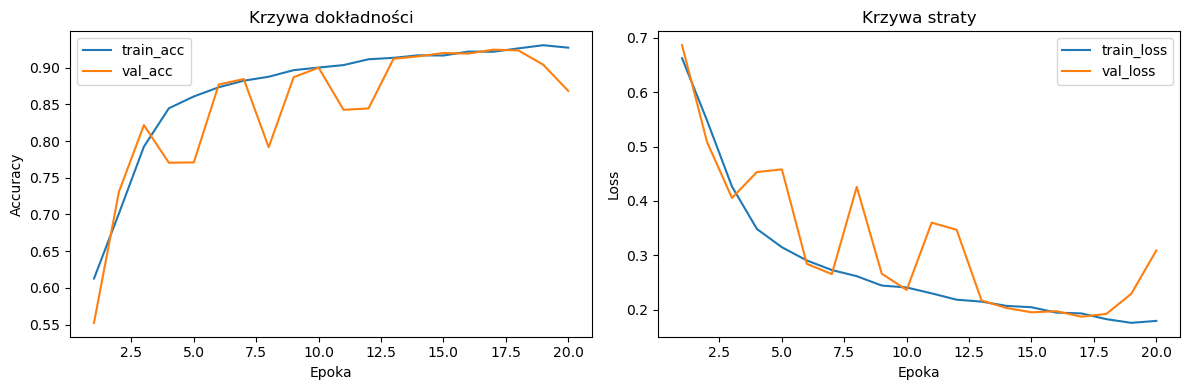

In [150]:
import matplotlib.pyplot as plt

acc      = history_big.history["accuracy"]
val_acc  = history_big.history["val_accuracy"]
loss     = history_big.history["loss"]
val_loss = history_big.history["val_loss"]

epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label="train_acc")
plt.plot(epochs_range, val_acc, label="val_acc")
plt.xlabel("Epoka")
plt.ylabel("Accuracy")
plt.title("Krzywa dokładności")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label="train_loss")
plt.plot(epochs_range, val_loss, label="val_loss")
plt.xlabel("Epoka")
plt.ylabel("Loss")
plt.title("Krzywa straty")
plt.legend()

plt.tight_layout()
plt.show()



=== Classification Report ===
              precision    recall  f1-score   support

       Happy       0.96      0.92      0.93      3673
         Sad       0.88      0.94      0.91      2525

    accuracy                           0.92      6198
   macro avg       0.92      0.93      0.92      6198
weighted avg       0.93      0.92      0.92      6198



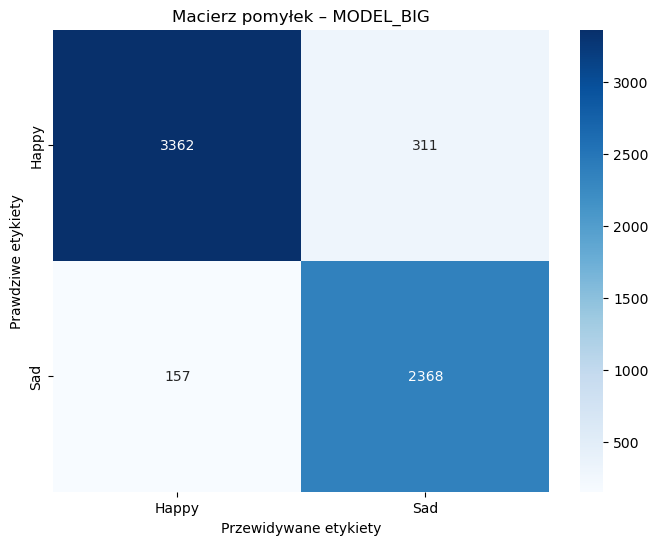

In [148]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

test_images = []
test_labels = []

for batch_images, batch_labels in test_ds.unbatch().batch(1000): 
    test_images.append(batch_images.numpy())
    test_labels.append(batch_labels.numpy())


test_images = np.vstack(test_images)
test_labels = np.hstack(test_labels)


y_pred_probs = model_big.predict(test_images, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)


print("\n=== Classification Report ===")
print(classification_report(test_labels, y_pred, target_names=class_names))

cm = confusion_matrix(test_labels, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Przewidywane etykiety")
plt.ylabel("Prawdziwe etykiety")
plt.title("Macierz pomyłek – MODEL_BIG")
plt.show()


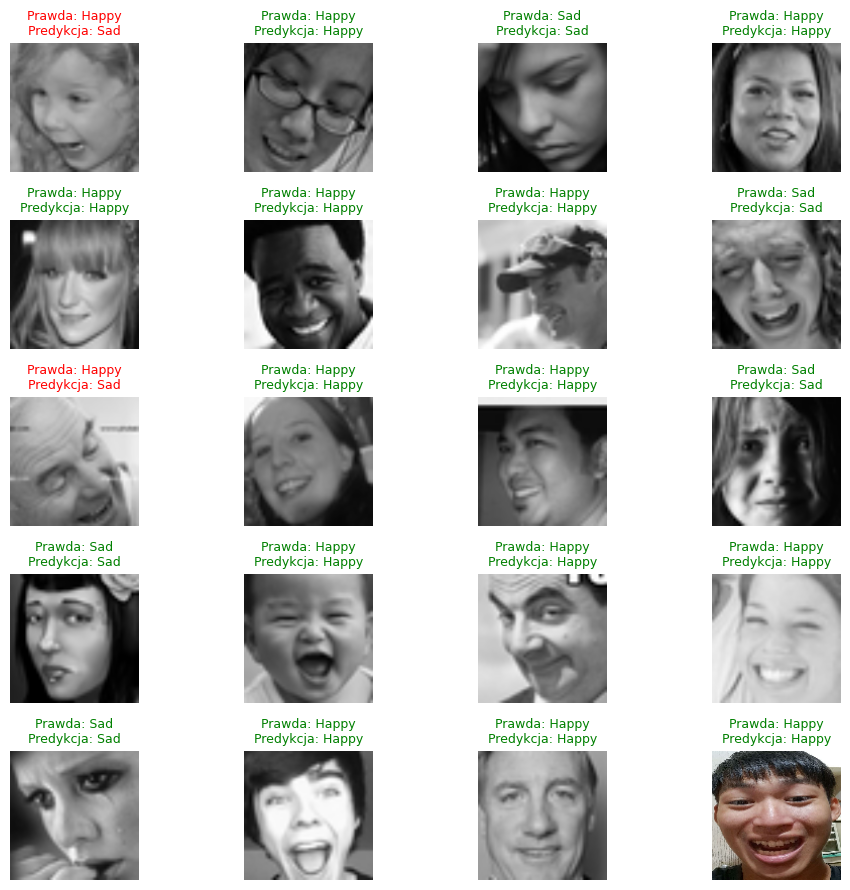

In [164]:
import numpy as np
import matplotlib.pyplot as plt


images, labels = next(iter(test_ds))   

pred_probs  = model_big.predict(images, verbose=0)
pred_labels = np.argmax(pred_probs, axis=1)


plt.figure(figsize=(10, 9))

num_to_show = 20  
for i in range(num_to_show):
    ax = plt.subplot(5, 4, i + 1)
    
    img = images[i].numpy()
    true_idx = int(labels[i].numpy())
    pred_idx = int(pred_labels[i])

    true_name = class_names[true_idx]
    pred_name = class_names[pred_idx]

    # kolor tytułu: zielony jeśli trafione, czerwony jeśli pomyłka
    color = "green" if true_idx == pred_idx else "red"

    plt.imshow(img.astype("float32"))
    plt.axis("off")
    ax.set_title(f"Prawda: {true_name}\nPredykcja: {pred_name}",
                 color=color, fontsize=9)

plt.tight_layout()
plt.show()